# Carregar as bibliotecas

In [2]:
import numpy as np
from skimage import io, data, filters, util, color, transform, exposure
from scipy import ndimage, stats, fft
import matplotlib.pyplot as plt
from skimage.util import img_as_float, img_as_uint, img_as_ubyte
from skimage.exposure import rescale_intensity

In [3]:
def show(img_list, caption_list, Axis=False, rescale = True):
    n = len(img_list)
    f, ax = plt.subplots(1,n, figsize=(10+5*(n-1),10))
    for i in range(n):
        if rescale:
            ax[i].imshow(img_list[i], cmap='gray')
        else:
            ax[i].imshow(img_list[i], cmap='gray', vmin=0, vmax=255)
        ax[i].set_title(caption_list[i])
        if not Axis:
            ax[i].set_axis_off()

In [4]:
def log_imshow(img):
    return np.log( np.abs(img)+1 )

In [5]:
def mapping(img):
    nimg = img_as_float(img)
    mmin = np.min(nimg)
    nimg = nimg - mmin
    mmax = np.max(nimg)
    return nimg/mmax

# Questão 1
<p align="justify">Mudar a cor do fundo (*background*) da imagem apresentada a continuação, ela deve estar em tons de azul claro e o corpo do fósforo em tons de amarelo. Além disso, é fornecido a imagem binária, onde os fósforos estão representados pela cor branca e o fundo pela cor preta. Use operações aritméticas para executar o processo de modificação do fundo. A continuação são mostradas a imagem em escala de cinza e a respectiva máscara.</p>


<table><tr>
<td>
<figure><img src="https://drive.google.com/uc?id=1V3OaLUh34dRCx-53PGsUYOMb1kZ1gqzo" alt="Drawing" width="300" class="center"/>
<figcaption>Imagem em escala de cinza</figcaption>
</figure>
</td>
<td>
<figure>
<img src="https://drive.google.com/uc?id=13NOF3oDNkmNtHCHmbX_9d0-AISPEmGZe" alt="Drawing" width="300" class="center"/>
<figcaption>Máscara</figcaption>
</figure>
</td>
</tr>
</table>


<p align="justify">DICA: para conseguir modificar a intensidade do fundo, incremente um valor $inc$ nos canais vermelho e verde, e incremente um valor $2*inc$ no canal azul. Preserve as intensidades originais dos fósforos. </p>


<p align="justify">A Figura a continuação mostra o resultado final. A imagem gerada deve ser colorida e o tecido (fundo da imagem) deve aparecer na cor azul claro. </p>

<center>
<figure>
<img src="https://drive.google.com/uc?id=1BILk7RPeAuurU7dGTi-tJLxvwfkxCFv5" alt="Drawing" width="300" class="center"/>
<figcaption>Imágem resultante</figcaption>
</figure>
</center>




In [6]:
def change_background(img, mask, inc = 30):
  lin, col = img.shape
  nimg = np.zeros((lin, col, 3))
  nimg[:,:,0] = img
  nimg[:,:,1] = img
  nimg[:,:,2] = img
  for i in range(lin):
    for j in range(col):
      if mask[i,j] == 0: #fundo
        nimg[i,j,0] += inc
        nimg[i,j,1] += inc
        nimg[i,j,2] += 2*inc
      elif img[i,j] > 50:
        nimg[i,j,0] += 2*inc
        nimg[i,j,1] += 2*inc
  return np.clip(nimg,0,255).astype(np.uint8)

(600, 600, 3)


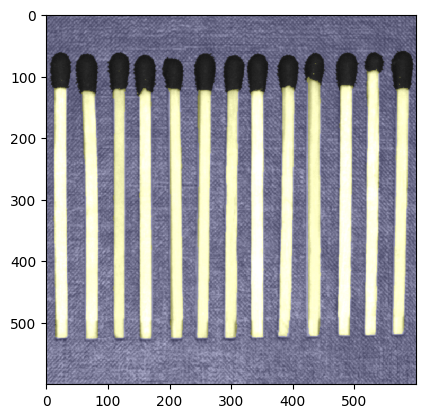

In [7]:
img = io.imread('https://drive.google.com/uc?id=1V3OaLUh34dRCx-53PGsUYOMb1kZ1gqzo')
mask = io.imread('https://drive.google.com/uc?id=13NOF3oDNkmNtHCHmbX_9d0-AISPEmGZe')
nimg = change_background(img, mask)
print(nimg.shape)
plt.imshow(nimg)

# Questão 2
<p>
A técnica de equalização de histograma permite modificar o histograma de uma imagem seguindo uma função de transformação padronizada. Embora seja um método bastante atrativo, não se trata de uma solução universal: em diversos casos, o resultado obtido pode não corresponder ao desejado, como ilustrado na figura a seguir. Na imagem à esquerda observa-se uma fotografia bastante escura da lua de Marte, enquanto à direita vê-se o resultado após a aplicação da equalização de histograma.
</p>

<table><tr>
<td>
<figure><img src="https://drive.google.com/uc?id=1W0PYWVB1wq4HgH-nRheuJmFlkGdlFVRr" alt="Drawing" width="300" class="center"/>
<figcaption>Imagem original</figcaption>
</figure>
</td>
<td>
<figure>
<img src="https://drive.google.com/uc?id=1Ka9j-lVMYZjaG6BuGVTHl26N3S6pVyVG" alt="Drawing" width="300" class="center"/>
<figcaption>Imagem Equalizada</figcaption>
</figure>
</td>
</tr>
</table>



<p>
Vejamos como realizar essa operação. Seja $F_1$ a função de distribuição cumulativa (CDF) da imagem de entrada e $F_2$ a CDF correspondente ao histograma alvo. O objetivo é determinar um mapeamento que transforme cada intensidade da imagem de entrada de modo que sua distribuição se aproxime da distribuição alvo. Assim, para cada intensidade $G_1$ da imagem de entrada, deve-se encontrar uma intensidade $G_2$ tal que: $F1(G1) = F2(G2)$.</p>

<p>
Na prática, nem sempre é possível obter essa igualdade exata. Nesses casos, busca-se a menor diferença absoluta entre $F_1(G1)$ e $F_2(G_2)$. Em outras palavras, para definir o mapeamento $M$, é preciso, para cada intensidade $G_1$, encontrar o valor $G_2$ que minimize essa diferença:
</p>

$$M(G_1) = arg min_{G_2 \in [0, 255]} |F_1(G_1) - F_2(G_2)| \textrm{,    } \forall G_1 \in [0,255]$$

<p>
Em essência, o processo consiste em, para cada valor de $F1(G_1)$, identificar o valor mais próximo em $F_2(G_2)$. Ou seja, para cada intensidade da imagem de entrada, calcula-se $F1(G_1)$, compara-se com todos os valores de $F_2(G_2)$, encontra-se aquele que produz a menor diferença e, por fim, associa-se essa intensidade $G_2$  ao mapeamento $M$.
</p>

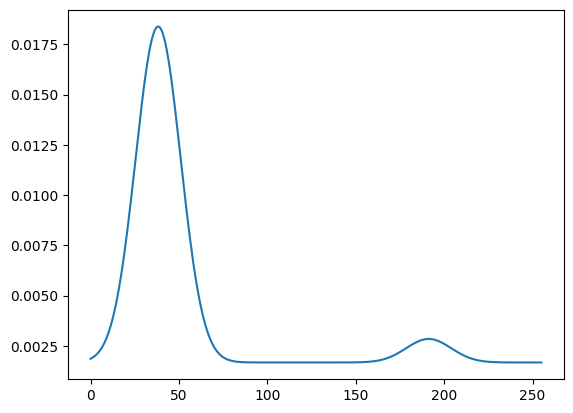

In [62]:
h = np.loadtxt('https://drive.google.com/uc?id=1n1uYESkn2TsD-8E0mH6K-4D7o1I5TwuX')
plt.plot(h)

In [63]:
def my_histogram_matching(img, hist):
  hist_img = ndimage.histogram(img, 0, 255, 256)
  hist_img = hist_img / np.sum(hist_img)

  cdf_hist = np.cumsum(hist)
  cdf_img = np.cumsum(hist_img)

  G = np.zeros((256))

  for i in range(256):
    pos = np.argmin(np.abs(cdf_img[i] - cdf_hist))
    G[i] = pos

  nimg = G[img]
  return nimg

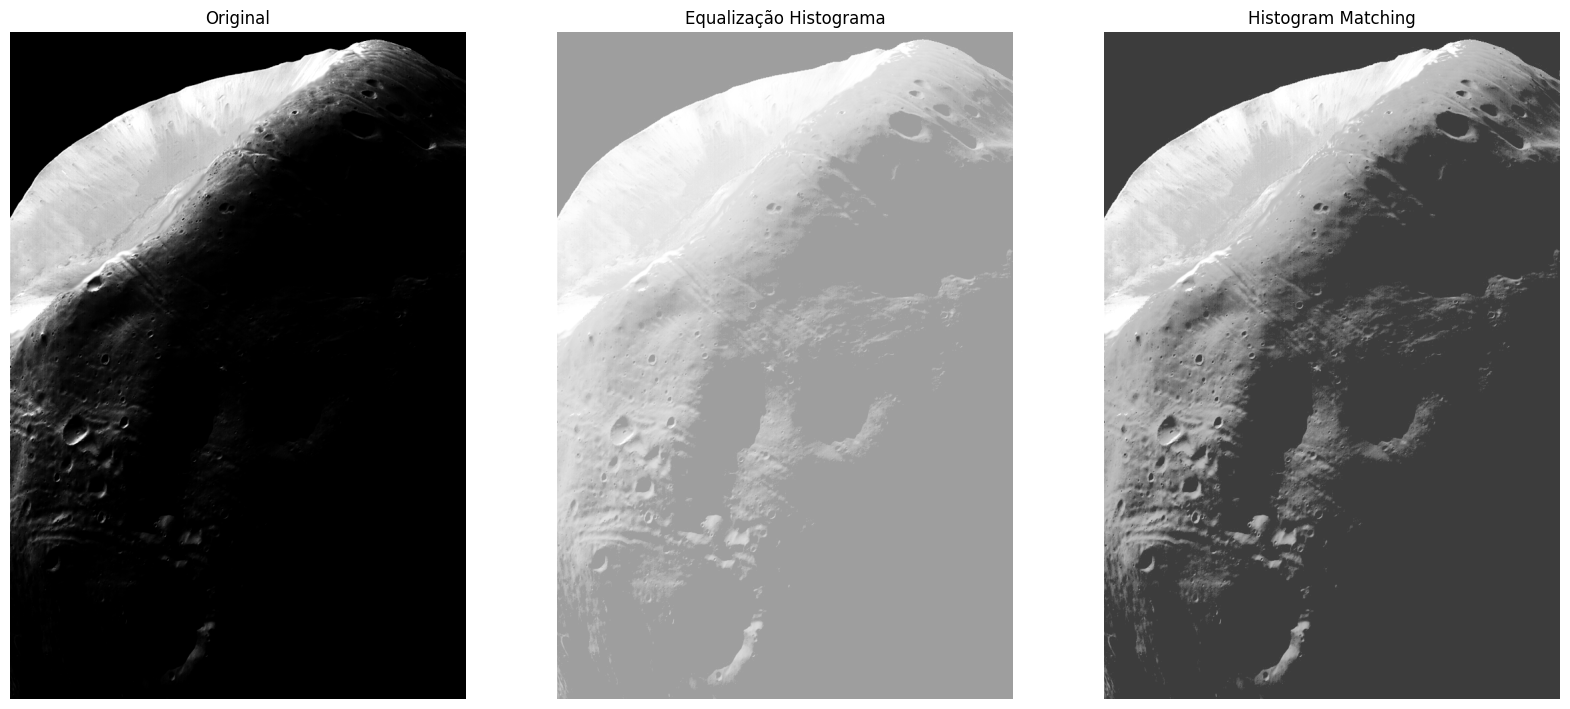

In [64]:
img_lua = io.imread('https://drive.google.com/uc?id=1W0PYWVB1wq4HgH-nRheuJmFlkGdlFVRr')
nimg = my_histogram_matching(img_lua, h)
img_eq = exposure.equalize_hist( img_lua, nbins = 256 )*255

show([img_lua, img_eq, nimg], ['Original', 'Equalização Histograma','Histogram Matching'], rescale = False)

# Questão 3
<p align="justify">
Modifique o código <i>my_histogram_matching()</i> para que receba uma segunda imagem como parâmetro. Essa segunda imagem será usada para ajustar seu histograma cumulativo e corresponda ao da outra.
</p>

In [67]:
def my_histogram_matching2(img, img_target):
  # Histograma e CDF da imagem fonte
  hist_src, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
  cdf_src = hist_src.cumsum()
  cdf_src = cdf_src / cdf_src[-1]

  # Histograma e CDF da imagem alvo
  hist_tgt, _ = np.histogram(img_target.flatten(), bins=256, range=[0, 256])
  cdf_tgt = hist_tgt.cumsum()
  cdf_tgt = cdf_tgt / cdf_tgt[-1]

  lookup_table = np.zeros(256, dtype=np.uint8)
  for i in range(256):
    diff = np.abs(cdf_tgt - cdf_src[i])
    lookup_table[i] = np.argmin(diff)
  
  nimg = lookup_table[img]

  return nimg.astype(np.uint8)

In [68]:
def histogram_matching_color(img, img_target):

  R = my_histogram_matching2(img[:,:,0], img_target[:,:,0])
  G = my_histogram_matching2(img[:,:,1], img_target[:,:,1])
  B = my_histogram_matching2(img[:,:,2], img_target[:,:,2])

  return np.dstack((R,G,B))

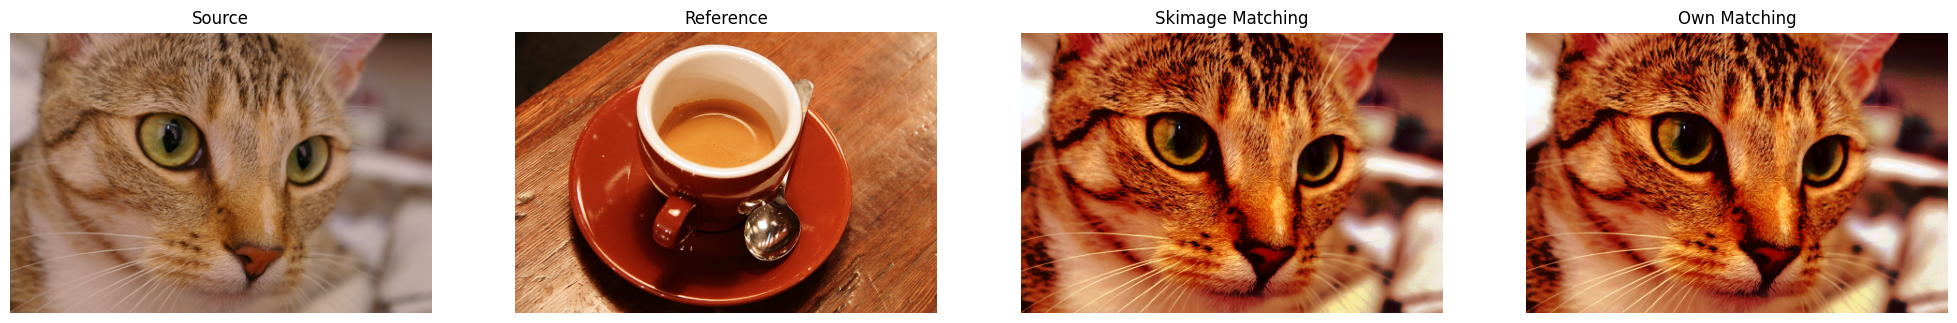

In [69]:
reference = data.coffee()
image = data.chelsea()

matchedSk = exposure.match_histograms(image, reference, channel_axis=2)
matched = histogram_matching_color(image, reference)

show([image,reference,matchedSk,matched],['Source','Reference','Skimage Matching','Own Matching'])

# Questão 4
<p align="justify">
Implementar o método de realce de imagens, onde $$f_{highpass}(x,y) = (1+G).f(x,y)-G.f_{mean}(x,y)$$
onde $0 \leq G \leq 2$, e $f_{mean}(x,y)$ é a imagem suavizada
</p>

In [70]:
def enhance(img, G=2, sigma=1):
    f_mean = filters.gaussian(img, sigma=sigma)
    nimg = (1+G) * img - G * f_mean
    nimg = np.clip(nimg, 0, 1)

    return nimg


In [71]:
lenna = io.imread('https://drive.google.com/uc?id=1k0FG4pT6WMjFeG-V63OBXNS7_CvfY5m_', as_gray=True)

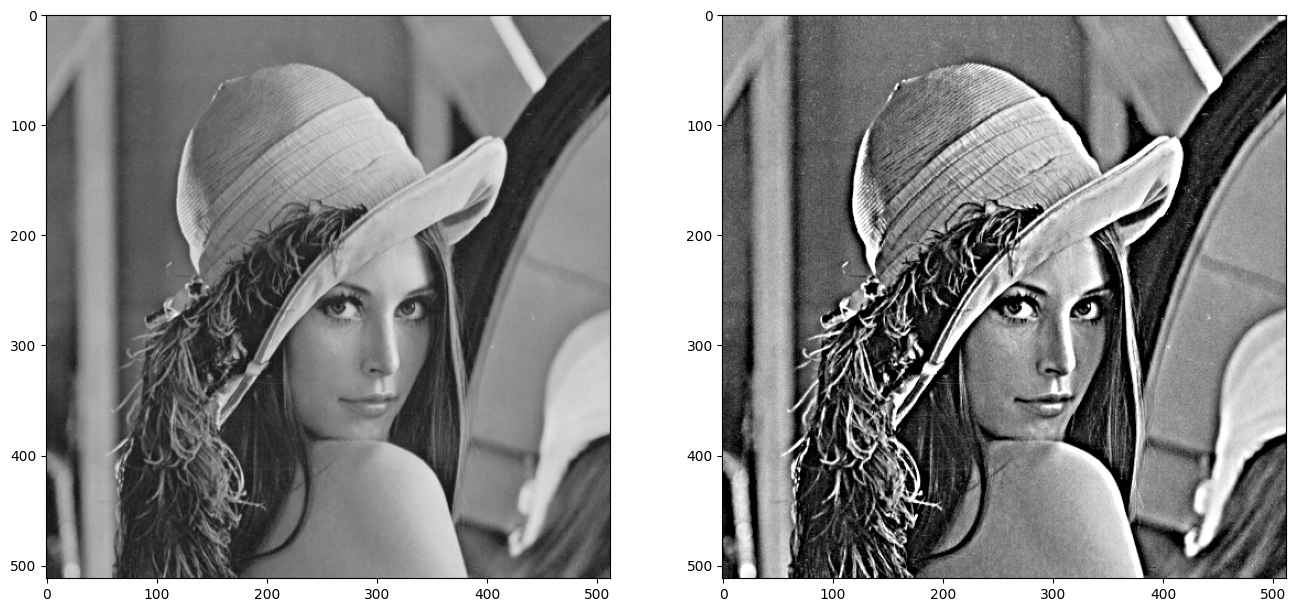

In [72]:
nimg = enhance(lenna, G=2, sigma=5)
f,ax = plt.subplots(1,2,figsize=(16,16))
ax[0].imshow(lenna, cmap='gray', vmin=0, vmax=1)
ax[1].imshow(nimg, cmap='gray', vmin=0, vmax=1)

## Questão 5

<p>Modifique o código da questão 4 para que realce as bordas de imagens coloridas</p>

In [83]:
def enhance_color(img, G=2, sigma=5):
    img_float = img.astype(np.float64) / 255.0

    R = enhance(img_float[:,:,0], G=G, sigma=sigma)
    G_ch = enhance(img_float[:,:,1], G=G, sigma=sigma)
    B = enhance(img_float[:,:,2], G=G, sigma=sigma)

    nimg = np.dstack((R, G_ch, B))
    return (nimg * 255).astype(np.uint8)



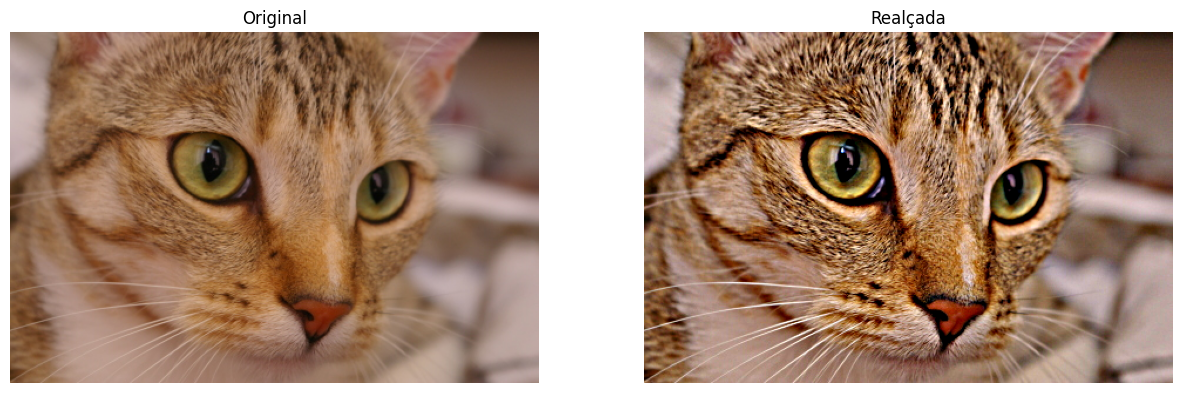

In [84]:
gato = data.chelsea()
nimg = enhance_color(gato)
show([gato,nimg],['Original','Realçada'])

# Questão 6

<p> Na seguinte imagem o valor das intensidades dos niveis de cinza estão concentrados na escala intermediaria. Verique isso calculando o histograma da imagem. Logo, corrija esse problema a través do algoritmo <i>contrast-stretching()</i>. </p>


<center>
<img src="https://drive.google.com/uc?id=1Tils6Uo-h2fh3JoTcsaMexoKR1AaMXqb" alt="Drawing" style="width: 250px;"/>
</center>


<p>
Realizar os seguinte passos:
<ol>
<li> Calcular o histograma da imagem</li>
<li> Implementar a função <i>constrast-stretching</i>.  Ela é definida da seguinte forma: $$s = T(r) = \frac{1}{1 + (m/r)^E}$$ onde $r$ denota a intensidade da imagem, $m$ é um valor dentro do intervalo [0,1] e $E$ um valor positivo. A intensidade $r$ da imagem deve estar normalizada entre [0,1]</li>
</ol>

<center>
<img src="https://drive.google.com/uc?id=1hPgC1WDTmuU8A2E6AeEXPmanf_vW81_a" alt="Drawing" width="230" />
</center>


</p>

In [52]:
def desenhaFuncao(m,E):
    pixel = np.linspace(0,1,256)
    s = 1/(1+(m/pixel)**E)
    plt.plot(pixel,s)

/tmp/ipykernel_230385/2522780556.py:3: RuntimeWarning: divide by zero encountered in divide
  s = 1/(1+(m/pixel)**E)


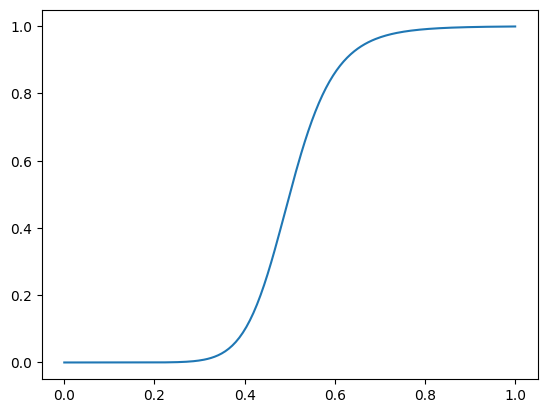

In [53]:
desenhaFuncao(m=0.5,E=10)

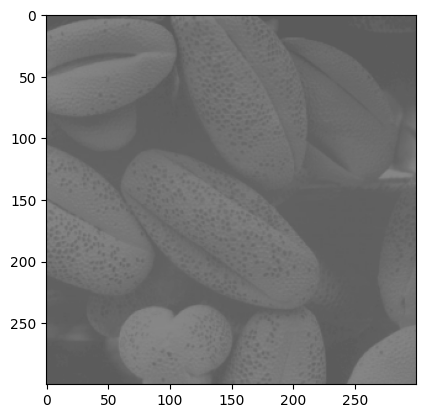

In [54]:
img2 = io.imread("https://drive.google.com/uc?id=1Tils6Uo-h2fh3JoTcsaMexoKR1AaMXqb")
plt.imshow(img2, cmap='gray', vmin =0, vmax=255)

### Calcular o histograma

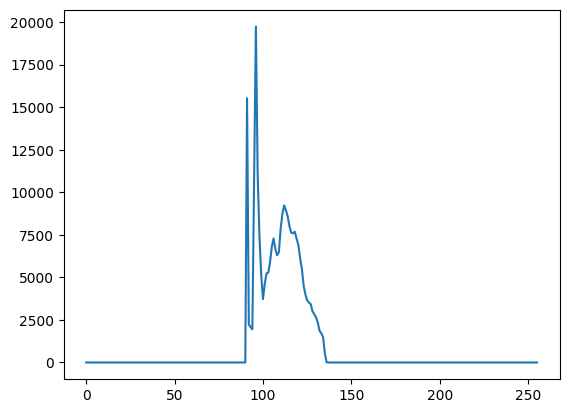

In [55]:
hist = ndimage.histogram(img2, min=0, max=255, bins=256)
plt.figure()
plt.plot(hist)

In [56]:
def constrast_streaching(img, m=0.5, E=2):
    nimg = img_as_float(img, force_copy=True)
    nimg = 1/(1+(m/nimg)**E)
    return nimg

### Aplicar a função contrast_streaching e recalcular o histograma

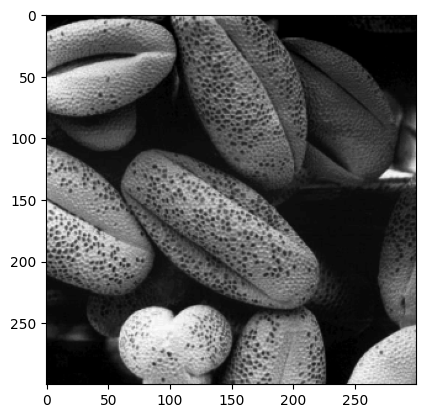

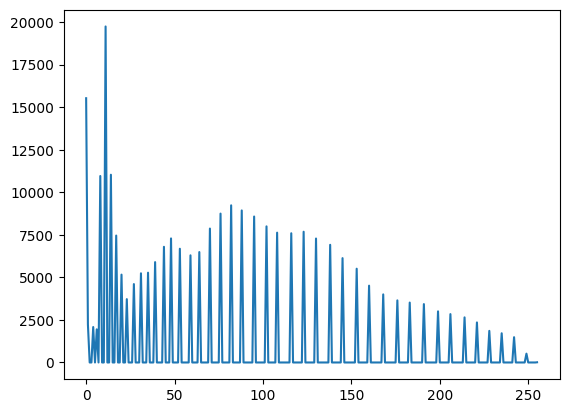

In [57]:
nimg = mapping(constrast_streaching(img2, m=0.5, E=9))
plt.imshow(nimg, cmap='gray', vmin=0, vmax=1)

h2 = ndimage.histogram(nimg, min=0, max=1, bins=256)
plt.figure()
plt.plot(h2)

### Realizar o mesmo processo com a seguinte imagem

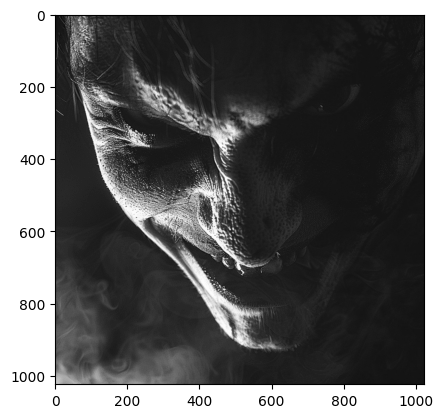

In [58]:
dark = io.imread('https://drive.google.com/uc?id=1o-E3q6ji1aNXBC519apXJfLk3eaSqYNw', as_gray=True)
plt.imshow(dark, cmap='gray')

### Cálculo do histograma

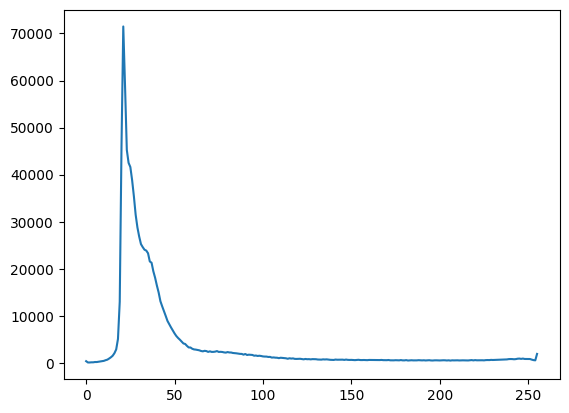

In [59]:
h = ndimage.histogram(dark, min=0, max=1, bins=256)
plt.figure()
plt.plot(h)

/tmp/ipykernel_230385/3971321790.py:3: RuntimeWarning: divide by zero encountered in divide
  nimg = 1/(1+(m/nimg)**E)


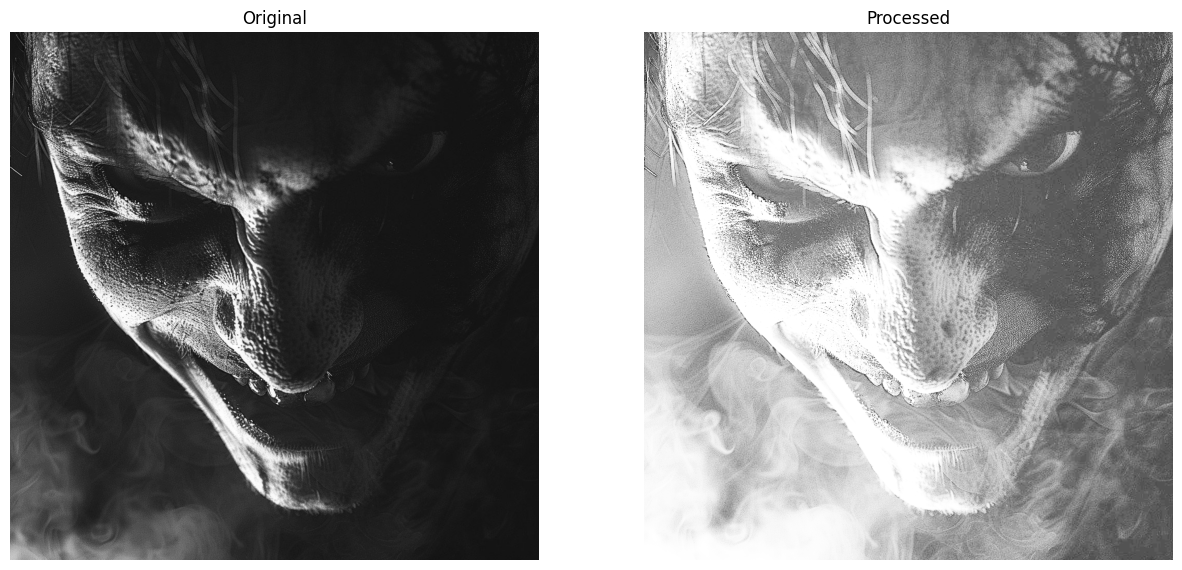

In [60]:
nimg = mapping(constrast_streaching(dark, m=0.1, E=3))
show([dark, nimg],['Original','Processed'])

### Modificar a imagem usando a tecnica de histogram matching

/tmp/ipykernel_230385/3971321790.py:3: RuntimeWarning: divide by zero encountered in divide
  nimg = 1/(1+(m/nimg)**E)


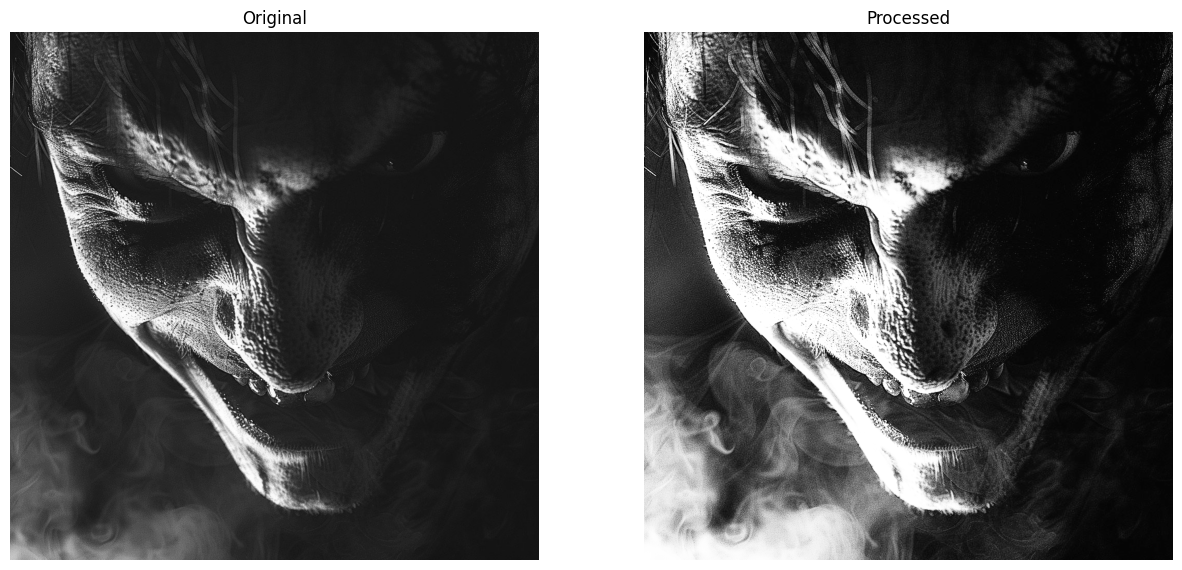

In [61]:
nimg2 = mapping(constrast_streaching(dark, m=0.2, E=4))
show([dark, nimg2],['Original','Processed'])